# Importing the Libraries

In [1]:
!pip install "protobuf<3.21"

import os
import sys
import re
import warnings
from tqdm import tqdm
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display
import soundfile as sf
import IPython.display as ipd
from IPython.display import Audio

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.models import Sequential, Model

from tensorflow.keras.layers import (
    Input, Dense, Flatten, Dropout, Activation, BatchNormalization,  # Core
    LSTM, GRU, Bidirectional, Embedding,                             # RNN / NLP
    Conv1D, MaxPooling1D, AveragePooling1D                           # CNN
)

# Keras Preprocessing
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Keras Callbacks & Optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import SGD

if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)

print(f"TensorFlow Version: {tf.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.0 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 3.20.3 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
tensorflow-me

2025-12-13 17:48:33.432451: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765648113.686513      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765648113.771039      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow Version: 2.18.0


In [2]:
!nvidia-smi
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

/bin/bash: line 1: nvidia-smi: command not found
[]


2025-12-13 17:48:51.164047: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
print("Loading data...")
X_train = np.load("/kaggle/input/processed-final-lstm-dataset/X_train (1).npy")
y_train = np.load("/kaggle/input/processed-final-lstm-dataset/y_train (1).npy")
X_test = np.load("/kaggle/input/processed-final-lstm-dataset/X_test (1).npy")
y_test = np.load("/kaggle/input/processed-final-lstm-dataset/y_test (1).npy")
print(f"Data Loaded. X_train shape: {X_train.shape}")

Loading data...
Data Loaded. X_train shape: (60486, 128, 42)


# LOAD MODEL


In [4]:
print("Loading the model...")
model = models.load_model("/kaggle/input/ser-last-version/keras/default/1/SER_model.keras")
print("Loaded successfully!")
model.summary()

Loading the model...
Loaded successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 42)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 128, 256)  │     54,016 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 256)  │      1,024 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 128, 256)  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 64, 256)   │          0 │ leaky_re_lu[0][0] │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 256)   │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 64, 128)   │    163,968 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 64, 128)   │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 32, 128)   │          0 │ leaky_re_lu_1[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 128)   │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 32, 512)   │    788,480 │ dropout_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32, 512)   │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 32, 512)   │  1,574,912 │ dropout_2[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32, 512)   │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 32, 256)   │    656,384 │ dropout_3[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32, 256)   │          0 │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 32, 256)   │    526,080 │ dropout_4[0][0],  │
│ (MultiHeadAttentio… │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 256)   │          0 │ dropout_4[0][0],  │
│                     │                   │            │ multi_head_atten

 Total params: 11,398,551 (43.48 MB)

 Trainable params: 3,799,175 (14.49 MB)

 Non-trainable params: 1,024 (4.00 KB)

 Optimizer params: 7,598,352 (28.99 MB)


--- Final Test Evaluation ---
314/314 ━━━━━━━━━━━━━━━━━━━━ 55s 161ms/step - accuracy: 0.8059 - loss: 0.7499
Test Accuracy: 80.61%
314/314 ━━━━━━━━━━━━━━━━━━━━ 52s 162ms/step


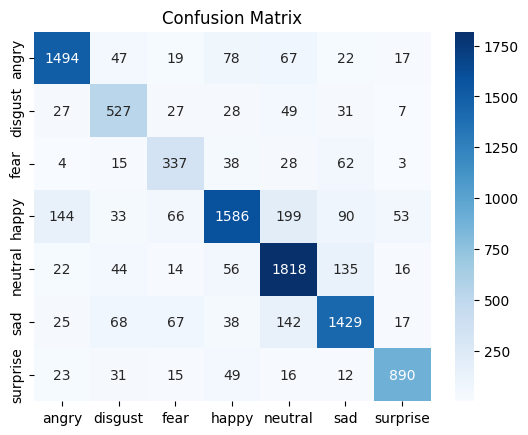


--- Detailed Report ---
              precision    recall  f1-score   support

       angry       0.86      0.86      0.86      1744
     disgust       0.69      0.76      0.72       696
        fear       0.62      0.69      0.65       487
       happy       0.85      0.73      0.78      2171
     neutral       0.78      0.86      0.82      2105
         sad       0.80      0.80      0.80      1786
    surprise       0.89      0.86      0.87      1036

    accuracy                           0.81     10025
   macro avg       0.78      0.79      0.79     10025
weighted avg       0.81      0.81      0.81     10025



In [5]:
# --- 5. EVALUATE ---
print("\n--- Final Test Evaluation ---")
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# Confusion Matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.subplot(1, 1, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.show()

# Classification Report (Precision/Recall per Emotion)
print("\n--- Detailed Report ---")
print(classification_report(y_true_classes, y_pred_classes, target_names=classes))

# Strip the Optimizer

In [6]:
model.save('ser_model_inference_only.keras', include_optimizer=False)

# Convert to TFLite

In [7]:
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
print("TensorFlow loaded in CPU mode.")

model_path = "/kaggle/input/ser-last-version/keras/default/1/SER_model.keras"
print(f"Loading model from {model_path}...")
model = tf.keras.models.load_model(model_path)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.target_spec.supported_ops = [
  tf.lite.OpsSet.TFLITE_BUILTINS, # Attempt native TFLite ops
  tf.lite.OpsSet.SELECT_TF_OPS    # Fallback to TensorFlow ops for complex layers
]

print("Converting model... (This might take a minute)")
tflite_model = converter.convert()

save_path = 'ser_model.tflite'
with open(save_path, 'wb') as f:
    f.write(tflite_model)

print(f"Success! Model saved to {save_path}")
print(f"File size: {len(tflite_model) / 1024 / 1024:.2f} MB")

TensorFlow loaded in CPU mode.
Loading model from /kaggle/input/ser-last-version/keras/default/1/SER_model.keras...
Converting model... (This might take a minute)
INFO:tensorflow:Assets written to: /tmp/tmpv4ay3xuf/assets


INFO:tensorflow:Assets written to: /tmp/tmpv4ay3xuf/assets


Saved artifact at '/tmp/tmpv4ay3xuf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 42), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  134684337503120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134684337504080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134684348377680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134684348381328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134684337497360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134684348380752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134684348367696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134684348380944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134684348376912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134684348377296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134684348378640: Te

W0000 00:00:1765648267.871774      13 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1765648267.871851      13 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1765648267.921365      13 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled


Success! Model saved to ser_model.tflite
File size: 3.86 MB


# Model Evaluation

Running TFLite inference on 10025 samples...


INFO: Created TensorFlow Lite delegate for select TF ops.
INFO: TfLiteFlexDelegate delegate: 8 nodes delegated out of 96 nodes with 4 partitions.

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Processed 10000/10025...
Inference complete.

--- TFLite Final Evaluation ---
TFLite Test Accuracy: 80.56%


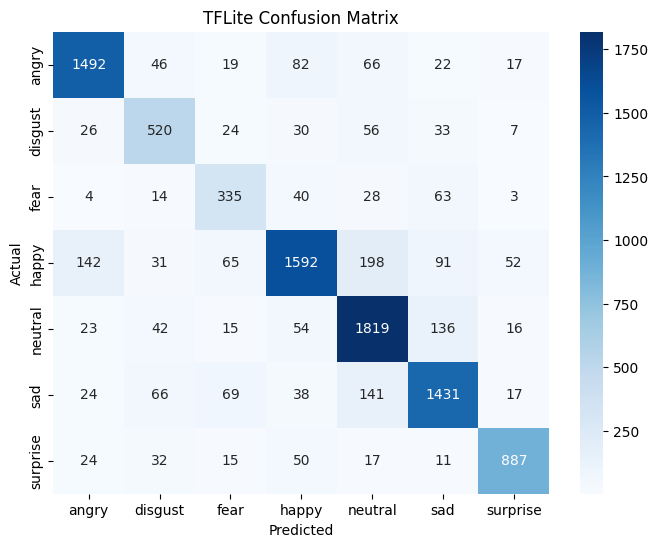


--- Detailed Report (TFLite) ---
              precision    recall  f1-score   support

       angry       0.86      0.86      0.86      1744
     disgust       0.69      0.75      0.72       696
        fear       0.62      0.69      0.65       487
       happy       0.84      0.73      0.78      2171
     neutral       0.78      0.86      0.82      2105
         sad       0.80      0.80      0.80      1786
    surprise       0.89      0.86      0.87      1036

    accuracy                           0.81     10025
   macro avg       0.78      0.79      0.79     10025
weighted avg       0.81      0.81      0.81     10025



In [8]:
interpreter = tf.lite.Interpreter(model_path="ser_model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
input_index = input_details[0]['index']
output_index = output_details[0]['index']

print(f"Running TFLite inference on {len(X_test)} samples...")
tflite_preds = []

for i, sample in enumerate(X_test):
    input_data = np.expand_dims(sample, axis=0).astype(np.float32)
    interpreter.set_tensor(input_index, input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_index)
    tflite_preds.append(np.argmax(output_data[0]))

    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1}/{len(X_test)}...", end='\r')

print("\nInference complete.")

y_true_classes = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test

acc = accuracy_score(y_true_classes, tflite_preds)
print(f"\n--- TFLite Final Evaluation ---")
print(f"TFLite Test Accuracy: {acc*100:.2f}%")

classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
cm = confusion_matrix(y_true_classes, tflite_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('TFLite Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\n--- Detailed Report (TFLite) ---")
print(classification_report(y_true_classes, tflite_preds, target_names=classes))